# **Ayundantia 4: Análisis y XAI con datos no estructurados (texto)**

# Curso: Inteligencia Artificial Aplicada
### Profesora: Carla Vairetti
### Ayudante: Samuel Aliaga (sialiaga@miuandes.cl)

## **Configuración**

Para garantizar el correcto funcionamiento del laboratorio, es necesario instalar las siguientes librerías en el entorno de trabajo. A continuación, se detallan los comandos necesarios para la instalación:


### Instalar Librerias

In [1]:
!pip install ipywidgets==7.7.1
!pip install lime
!pip install transformers-interpret
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=eefc56fe4b171706a93732df47a3774686764265e7c4a3ae853baa4b0dcf3a41
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uni

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 95.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.0.2 which is incompatible.


### LLamar a un archivo en Google Drive

El siguiente paso es montar Google Drive para poder enlazar nuestra base de datos.

**Cuando corra la siguiente línea, siga las intrucciones indicando la cuenta de Google correspondiente y aceptando las condiciones.**

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Contexto

Estos datos de entrenamiento están relacionados con un conjunto de datos creado mediante web scraping de la página Metacritic (reseñas de juegos). Para ello, se realizó una tarea de clasificación de «sentimientos» con tres clases, en este caso relacionadas con las críticas, para la que se utilizó Distilbert y una versión prefinetuned de Distilbert.

In [3]:
import pandas as pd

df = pd.read_pickle('/content/drive/MyDrive/IA_Aplicada/2026/IAA_Ayundatias_2026/IAA_ayun04_2026/game_reviews_preprocess.pkl')

In [4]:
df

,texts,labels,conjunto
0,well worth look youre seeking comfort nostalgi...,1,TRAIN
1,<game> <game> <game> lovely piece gaming histo...,1,TRAIN
2,surely offers quirky fun gameplay <game> held ...,0,TRAIN
3,<game> offers pleasingly brisk enjoyable forma...,1,TRAIN
4,<game> <game> iii <game> lovingly reworked cla...,1,TRAIN
...,...,...,...
2117,games lacking heart soul titles set universe <...,0,EVAL
2118,core still extremely good action roleplaying g...,0,EVAL
2119,<game> <game> refreshingly mature turn nintend...,1,EVAL
2120,crucibles everymanforhimself combat tedious re...,-1,EVAL


## Análisis de las Métricas de Entrenamiento

En el laboratorio anterior se obtuvieron muchos datos, los cuales pueden resultar confusos si no se tiene claro qué función cumplen realmente. Las principales métricas obtenidas son:

### Métricas por Época  
- **Accuracy**: Mide el rendimiento general del modelo en la época *n*.  
- **Macro avg**: El promedio de todas las métricas del modelo en la época *n*.  
- **Weighted avg**: El promedio de todas las métricas usando un peso en relación a la cantidad de ejemplos de cada clase en la época *n*.  

### Métricas por Época y Clase  
- **Precision**: Mide el rendimiento del modelo para la clase *p* en la época *n*.  
- **Recall**: Mide cuántos casos reales de una clase *p* se identificaron correctamente en la época *n*.  
- **F1-score**: Mide la media armónica entre precision y recall para la clase *p* en la época *n*.  
- **Support**: Cantidad de muestras evaluadas para la clase *p* en la época *n*.  

En la siguiente sección realizaremos un análisis de todas.  

### Librerias

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Cargar Datos

In [6]:
# Ruta base en Google Drive
base_path = "/content/drive/MyDrive/IA_Aplicada/2026/IAA_Ayundatias_2026/IAA_ayun04_2026/results"

# Configuración de carpetas y etiquetas
folder_filter = ["train_metacritic"]
label_filter = {
    "results_distilbert": "Distilbert Base",
    "results_distilbert-sentiments.csv": "Distilbert Ajustado Emociones"
}

In [7]:
results = {}

# Listar contenido del directorio base
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    # Verificar si es un directorio y cumple con los filtros
    if not os.path.isdir(folder_path):
        continue

    if folder_filter and folder not in folder_filter:
        continue

    # Procesar el folder
    if ".ipynb" not in folder:
        folder_tag = label_filter.get(folder, folder.replace("_", " ")).upper()
        results[folder_tag] = {}

        # Listar archivos en el subdirectorio
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            # Verificar si es un archivo CSV y no es un notebook
            if os.path.isfile(file_path) and ".ipynb" not in file and ".csv" in file:
                sub_folder_tag = file.replace("results_", "").replace(".csv", "").upper()
                results[folder_tag][sub_folder_tag] = pd.read_csv(file_path)

In [8]:
print("Estructura de resultados cargados:")
for folder_tag, content in results.items():
    print(f"\n{folder_tag}:")
    for sub_tag in content.keys():
        print(f"  - {sub_tag}")

Estructura de resultados cargados:

TRAIN METACRITIC:
  - DISTILBERT
  - DISTILBERT-SENTIMENTS


### Herramientas

#### Metrica por epoca

In [9]:
def get_metric_per_epoch_graphs(label_names: list, metric='precision'):
    for conjunto, models in results.items():
        # Configuración inicial basada en el número de labels
        use_subplots = len(label_names) > 1
        fig, ax = plt.subplots(1, len(label_names), figsize=(15, 5)) if use_subplots else (None, None)

        if not use_subplots:
            plt.figure(figsize=(12, 6))

        for model_name, df in models.items():
            for i, label in enumerate(label_names):
                label_data = df[df['label'] == label]
                current_ax = ax[i] if use_subplots else plt.gca()

                current_ax.plot(
                    label_data['epoch'],
                    label_data[metric],
                    marker='o',
                    label=f'{model_name}' if use_subplots else f'{model_name} - Label {label}'
                )

        # Configuración de los gráficos
        if use_subplots:
            for i, label in enumerate(label_names):
                ax[i].set_title(f'Label {label} - {conjunto}')
                ax[i].set_xlabel('Época')
                ax[i].set_ylabel(metric.capitalize())
                ax[i].grid(True)
                ax[i].legend()
        else:
            plt.title(f'{metric.capitalize()} por época - {conjunto}')
            plt.xlabel('Época')
            plt.ylabel(metric.capitalize())
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)

        plt.tight_layout()
        plt.show()



In [10]:
def plot_last_epoch_barplot(label_names: list, metric='precision'):
    # Configurar figura con subgráficos para cada label
    fig, axes = plt.subplots(1, len(label_names), figsize=(10, 6))
    if len(label_names) == 1:
        axes = [axes]  # Convertir en lista para consistencia

    for i, label in enumerate(label_names):
        # Preparar datos para el gráfico de barras
        model_data = {}

        # Recopilar datos de la última época para cada modelo y conjunto
        for conjunto, models in results.items():
            for model_name, df in models.items():
                last_epoch_data = df[(df['label'] == label)].iloc[-1]  # Última época
                if model_name not in model_data:
                    model_data[model_name] = {}
                model_data[model_name][conjunto] = last_epoch_data[metric]

        # Convertir a formato adecuado para gráfico de barras agrupadas
        conjuntos = list(results.keys())
        models = list(model_data.keys())
        x = np.arange(len(conjuntos))  # Posiciones de las barras
        width = 0.8 / len(models)  # Ancho de las barras

        # Dibujar barras para cada modelo
        for j, model_name in enumerate(models):
            values = [model_data[model_name][c] for c in conjuntos]
            axes[i].bar(x + j*width, values, width, label=model_name)

        # Configuración del subgráfico
        axes[i].set_title(f'Label {label} - Última Época')
        axes[i].set_xlabel('Conjuntos')
        axes[i].set_ylabel(metric.capitalize())
        axes[i].set_xticks(x + width*(len(models)-1)/2)
        axes[i].set_xticklabels(conjuntos)
        axes[i].legend()
        axes[i].grid(True, axis='y')

    plt.tight_layout()
    plt.show()

### Analisis de Metricas

#### Accuracy

Esta métrica mide el rendimiento general del modelo, sin embargo puede omitir o sesgar ciertos detalles de las clases. Por lo tanto, su uso es muy genérico y basarse únicamente en ella puede ser impreciso. No obstante, proporciona una visión global del desempeño del modelo.

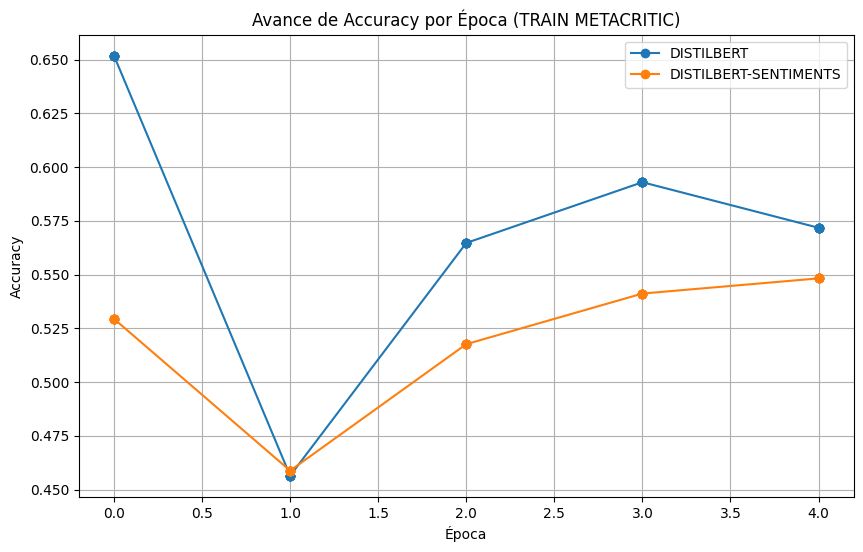

In [11]:
    for conjunto, models in results.items():
        metric = 'accuracy'
        plt.figure(figsize=(10, 6))
        for model_name, df in models.items():
            plt.plot(df['epoch'], df[metric], marker='o', label=model_name)
        plt.title(f"Avance de {metric.capitalize()} por Época ({conjunto})")
        plt.xlabel("Época")
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.show()

Como se puede ver, el rendimiento de DistilBERT desciende y luego aumenta; tal vez con unas cuantas épocas más se hubieran obtenido mejores resultados. Sin embargo, para ello quizá habría que implementar el método early-stopping, que consiste en parar el entrenamiento cada n épocas y revisar cómo va el modelo en términos de rendimiento. Por otro lado, DistilBERT-sentiments parece encontrar cierto equilibrio; quizá más épocas hubieran afectado al rendimiento.

<Figure size 1000x600 with 0 Axes>

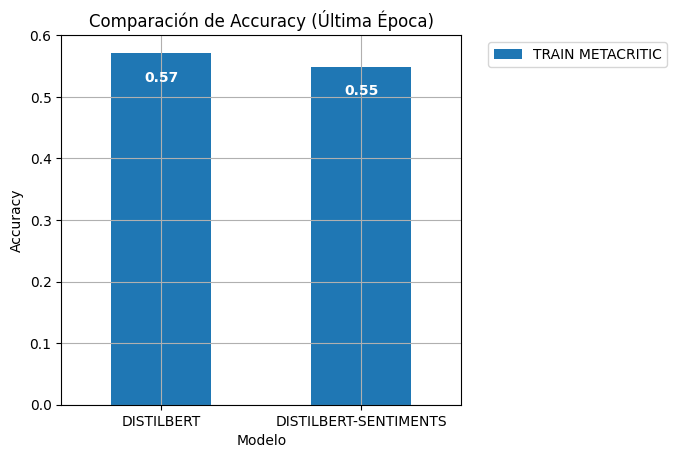

In [12]:
metric = 'accuracy'
comparison_data = []
for conjunto, models in results.items():
    for model_name, df in models.items():
        last_epoch_data = df[df['epoch'] == df['epoch'].max()]
        comparison_data.append({
            "Conjunto": conjunto,
            "Modelo": model_name,
            metric: last_epoch_data[metric].values[0],
        })

comparison_df = pd.DataFrame(comparison_data)

# Accuracy comparison
plt.figure(figsize=(10, 6))  # Tamaño de la figura
subset = comparison_df.pivot(index="Modelo", columns="Conjunto", values=metric)
ax = subset.plot(kind="bar", rot=0, legend=True)
plt.title(f"Comparación de {metric.capitalize()} (Última Época)")
plt.ylabel(metric.capitalize())
plt.xlabel("Modelo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Agregar los valores sobre cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                (p.get_x() + p.get_width() / 2., height * 0.95),  # 95% de la altura de la barra
                ha='center', va='top',  # Alineación arriba y centrada
                color='white' if height > (ax.get_ylim()[1] * 0.5) else 'black',  # Color automático
                fontsize=10,
                fontweight='bold')

plt.subplots_adjust(right=0.75)  # Ajusta el margen derecho para dejar espacio a la leyenda
plt.show()

Parece que Distilbert es mejor que Distilbert-Sentiments, sin embargo, la diferencia es mínima. Sin embargo, esta métrica no lo es todo a la hora de determinar cuál «es mejor».

#### Macro Avg
Esta métrica calcula el promedio simple de las métricas (precision, recall, f1) para todas las clases. Es útil cuando se quiere dar igual importancia a cada clase, independientemente de su tamaño. Sin embargo, puede verse afectada por clases con bajo rendimiento, dando una visión menos optimista del modelo cuando hay desbalance de clases.

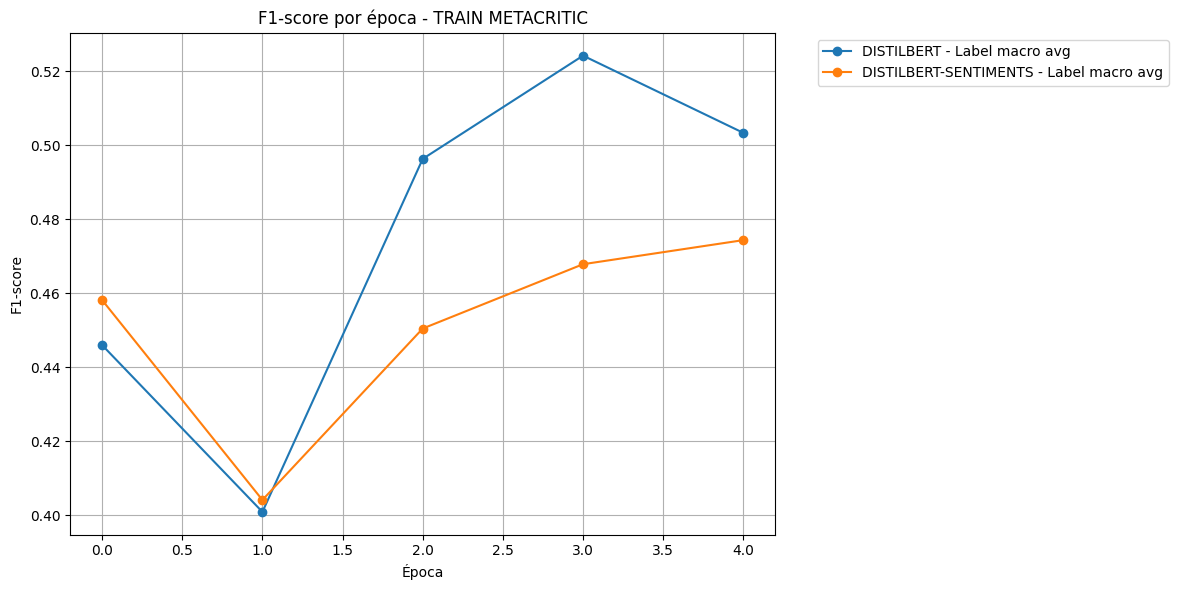

In [13]:
get_metric_per_epoch_graphs(['macro avg'], 'f1-score')

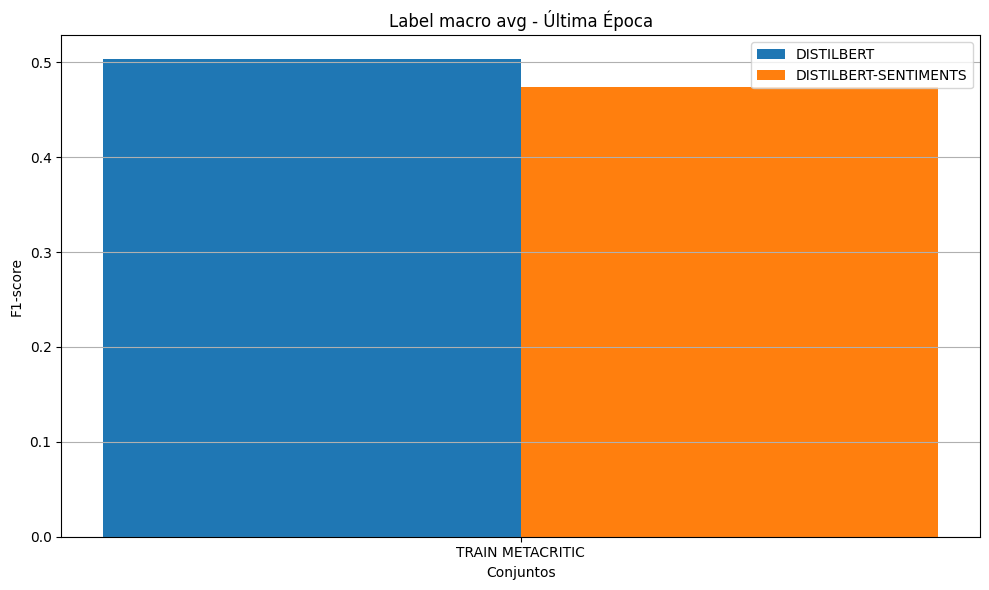

In [14]:
plot_last_epoch_barplot(['macro avg'], 'f1-score')

En este caso, no es necesario preocuparse tanto por esta métrica.

#### Weighted Avg
Calcula el promedio de las métricas ponderando cada clase según su cantidad de muestras (support). Es más representativa que macro avg cuando las clases están desbalanceadas, ya que da más peso a las clases con mayor cantidad de ejemplos. No obstante, puede enmascarar el bajo rendimiento en clases minoritarias.

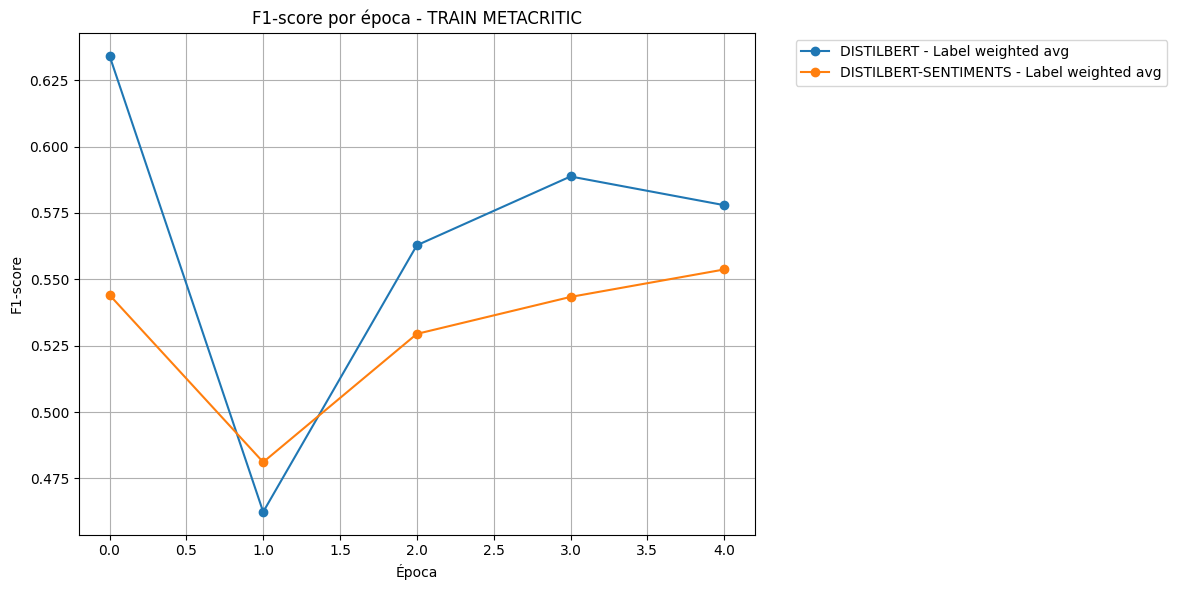

In [15]:
get_metric_per_epoch_graphs(['weighted avg'], 'f1-score')

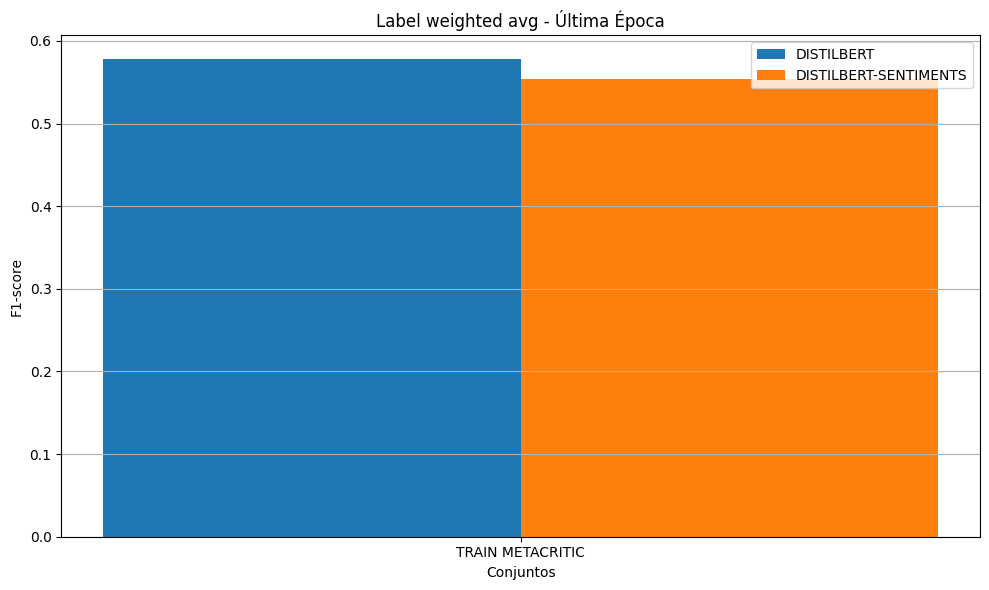

In [16]:
plot_last_epoch_barplot(['weighted avg'], 'f1-score')

En este caso, esta métrica podría ser útil para seleccionar el modelo, ya que tiene en cuenta el desequilibrio y el F1-score (más adelante lo trataremos).

### Precision
Indica qué porcentaje de predicciones positivas para una clase fueron correctas. Es crucial cuando los falsos positivos son costosos (ej: diagnóstico médico). Una alta precisión significa pocos falsos positivos, pero no garantiza que se detecten todos los casos reales (recall).

Ejemplo: El modelo identificó 80 reseñas como positivas y, de esas 80 reseñas que tu programa marcó como positivas, solo 70 eran realmente positivas. Las otras 10 eran, en realidad, neutrales o negativas (tu programa se equivocó).

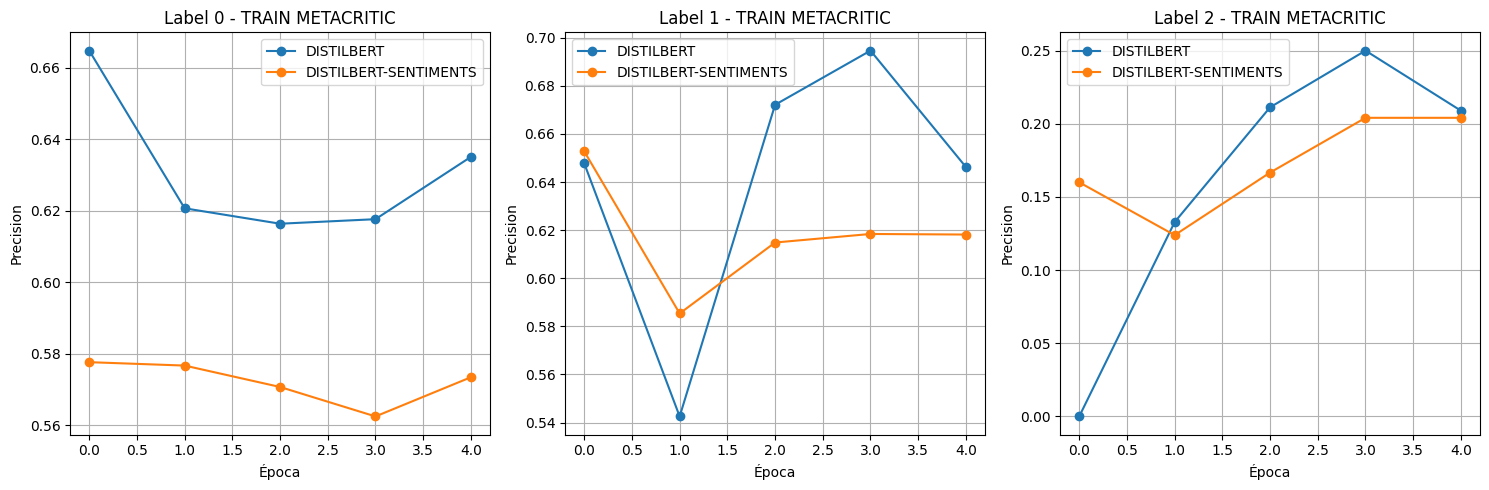

In [17]:
get_metric_per_epoch_graphs(['0', '1', '2'], 'precision')

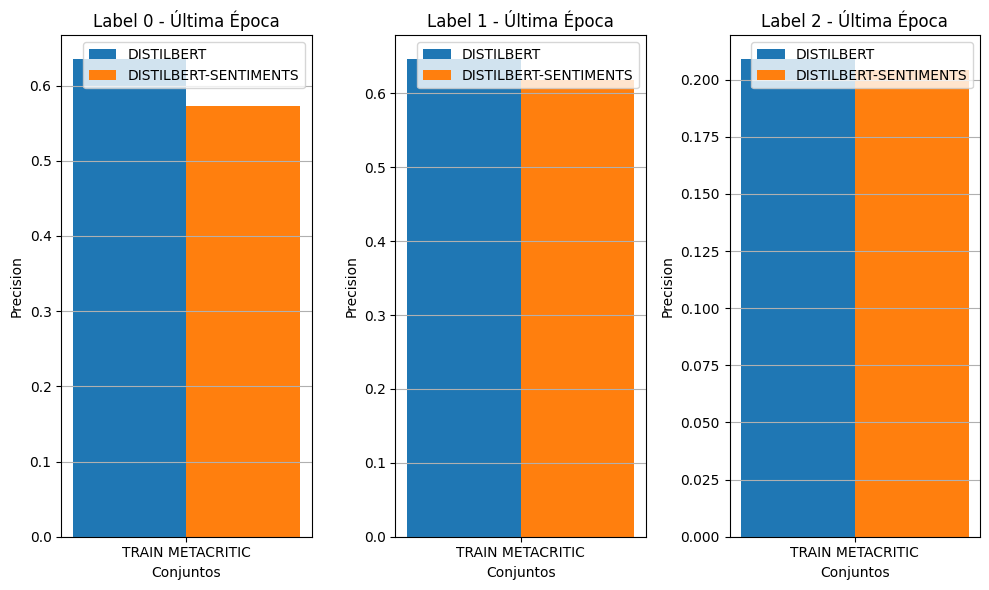

In [18]:
plot_last_epoch_barplot(['0', '1', '2'], 'precision')

Distilbert parece tener superioridad, sin embargo, aún hay que revisar las otras métricas.

### Recall
Mide qué porcentaje de casos reales de una clase fueron identificados correctamente. Es vital cuando los falsos negativos son críticos (ej: detección de fraudes). Alto recall significa pocos falsos negativos, pero puede venir a costa de más falsos positivos.

Ejemplo: Hay 100 reseñas que son realmente positivas y el modelo identifica 80 como positivas. Esto significa que el modelo identificó o recuperó el 80 % de todas las reseñas positivas. Se le escaparon 20 valoraciones positivas.

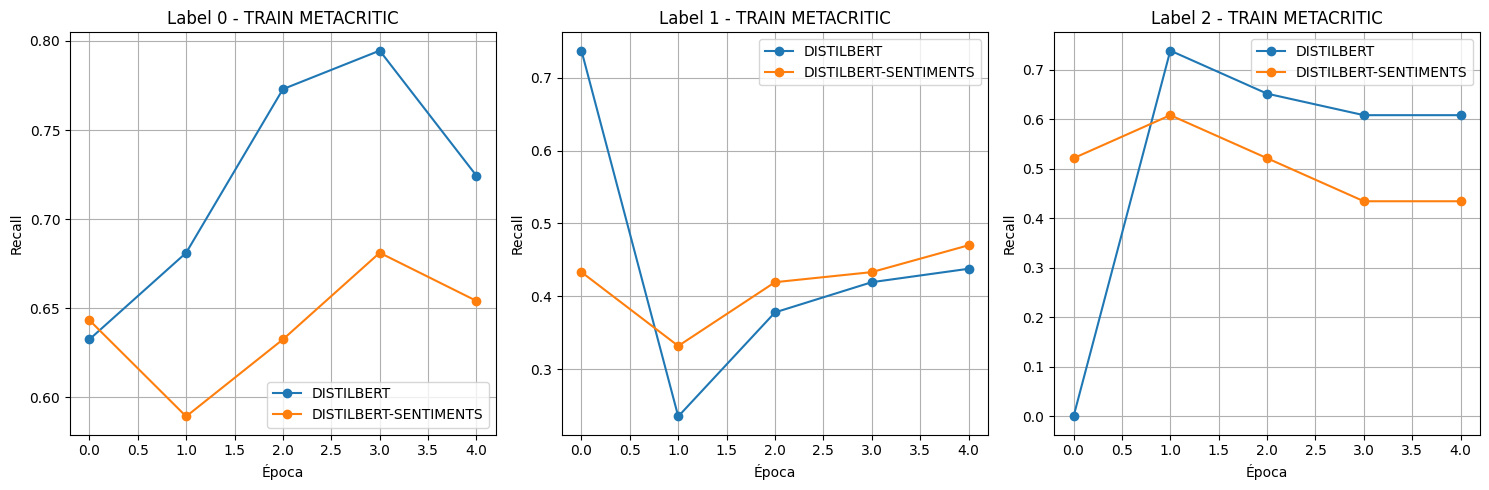

In [19]:
get_metric_per_epoch_graphs(['0', '1', '2'], 'recall')

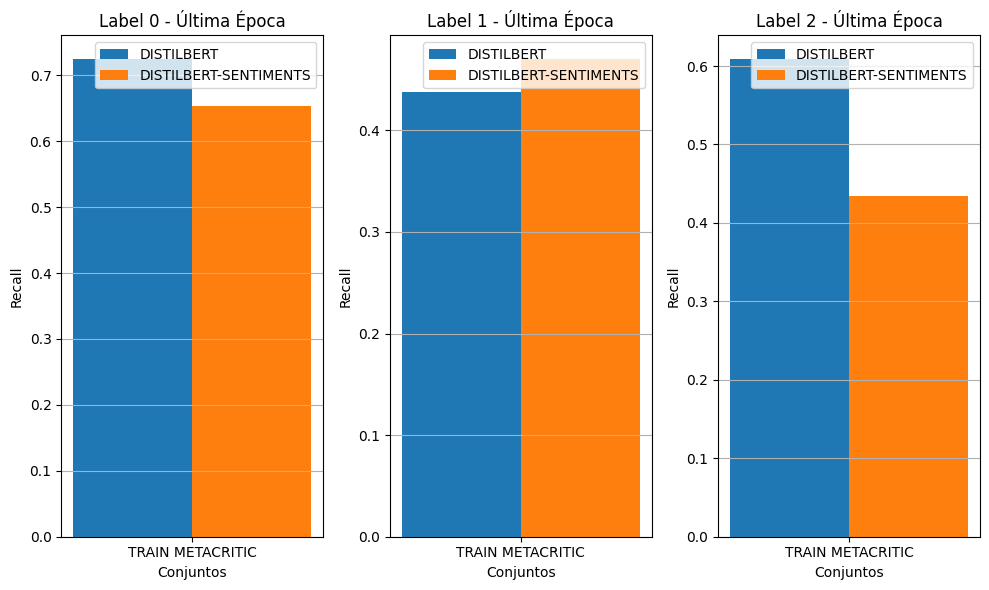

In [20]:
plot_last_epoch_barplot(['0', '1', '2'], 'recall')

Esta métrica se vuelve a decantar por Distilbete, sin embargo, ahora debemos centrarnos en la siguiente.

### F1-Score
Combina precision y recall en una sola métrica armónica. Es especialmente útil cuando se busca un balance entre evitar falsos positivos (precision) y falsos negativos (recall). Valores altos indican que el modelo mantiene buen equilibrio entre ambas métricas.

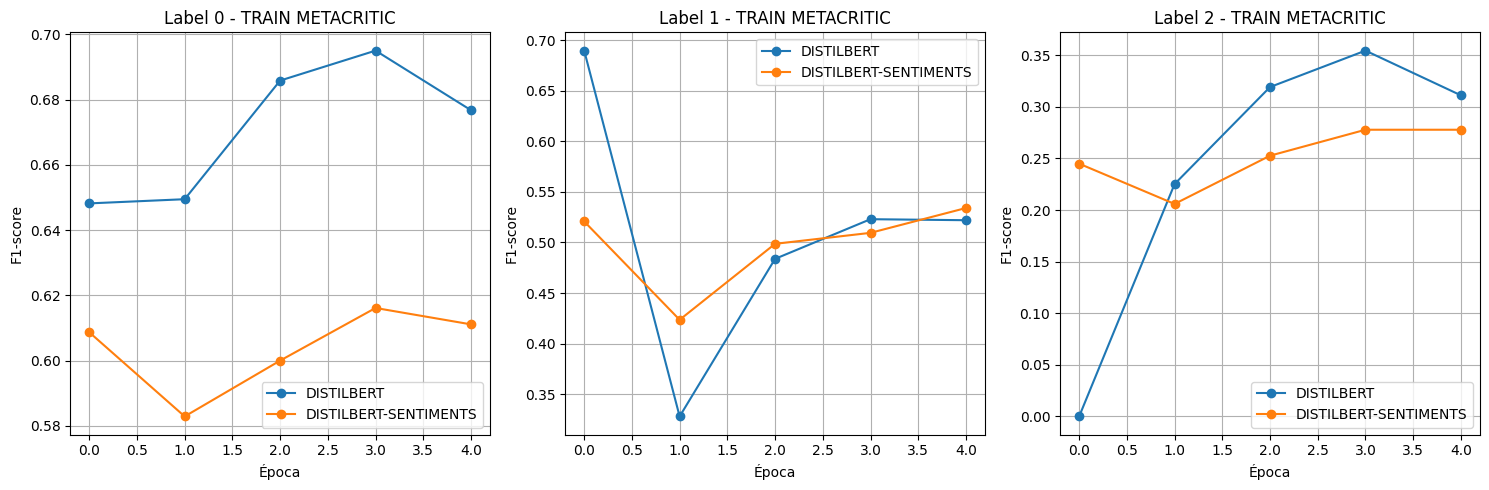

In [21]:
get_metric_per_epoch_graphs(['0', '1', '2'], 'f1-score')

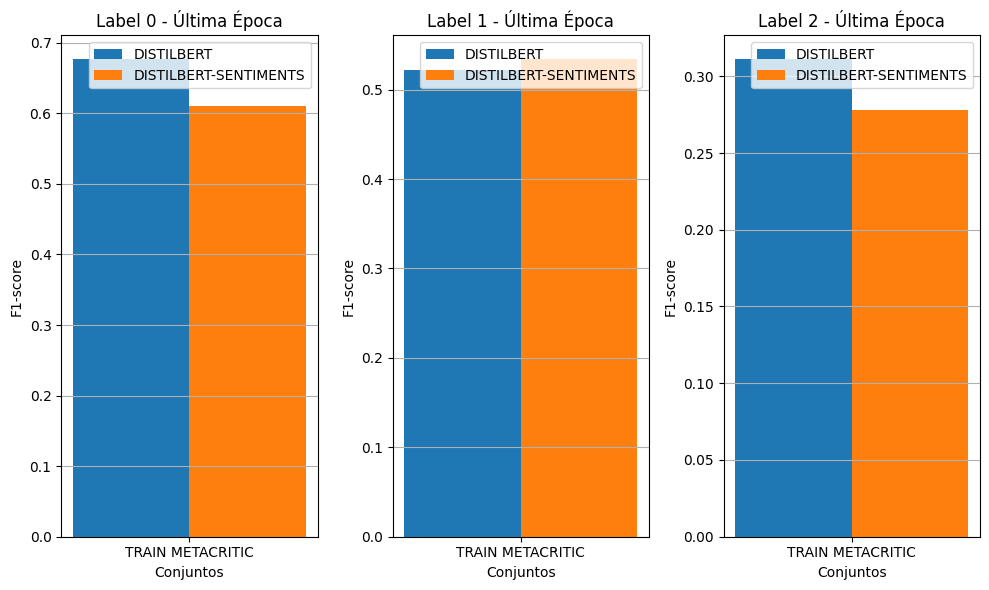

In [22]:
plot_last_epoch_barplot(['0', '1', '2'], 'f1-score')

Esta métrica es clave para nuestro caso con tres clases, ya que los valores apuntan una vez más a que Distilbert es mejor, aunque las diferencias no son exageradas, sino mínimas.
Ahora bien, ¿por qué es mejor DistilBERT que DistilBERT-Sentiment? Probablemente se deba a que los ajustes del segundo entorpecen con los patrones que se pueden obtener de la base de datos; sin embargo, las variaciones son mínimas, por lo que supondría una pequeña afectación.

Otro aspecto a destacar es que el f1-score para la clase negativa es muy bajo, aunque estamos comparando ambos modelos, también es importante analizar su rendimiento por sí mismo, por lo que ambos modelos están teniendo resultados realmente malos.

Por último, cabe señalar que esta métrica es importante cuando estamos trabajando con más de una clase; en caso de trabajar con dos clases, sería más útil centrarnos en el [AUC](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc?hl=es-419).

### Support
Indica el número de muestras reales de cada clase usadas en la evaluación. Permite identificar problemas de desbalanceo en los datos y contextualizar el significado de las otras métricas.

Dado que no es muy útil, realmente no lo suelo guardar. Tampoco lo hago con los gráficos, pues para eso están las otras métricas. (Lo siento 🙃)

## Herramientas adicionales de Análisis de Modelos

En el laboratorio anterior generamos un modelo (los pesos entrenados) que puede producir resultados, pero sin explicación clara de su proceso de decisión (la llamada "caja negra"). Para interpretar estos modelos, existen varias herramientas:

### Métricas por Época

- **LIME** (*Local Interpretable Model-agnostic Explanations*): Explica predicciones individuales creando modelos locales interpretables alrededor de cada instancia.

- **transformers-interpret**: Librería especializada para explicar predicciones de modelos Transformer (BERT, GPT, etc.) mediante atención y atribución de características.

- **SHAP** (*SHapley Additive exPlanations*): Método basado en teoría de juegos que asigna valores de importancia a cada característica para cada predicción.



### Librerias

In [23]:
from transformers import DistilBertForSequenceClassification, AutoTokenizer
import torch

### Texto de ejemplo

En este caso, usaremos un texto positivo, pues es el que más datos tiene y, probablemente, el que mejor prediga.

In [30]:
text = "The biggest, most heartpounding and awe-inspiring quest of all. Oh yes, Zelda 64 does indeed own your soul."

### Definir la arquitectura del modelo

Esta es la configuracion, esta netamente basada en como entrenamos el modelo, como decia algo tosco pero sirve para el caso.

In [31]:
model_name = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"  # Nombre del modelo preentrenado

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.add_special_tokens({'additional_special_tokens': ['<game>']})

model = DistilBertForSequenceClassification.from_pretrained(model_name).to(device)
model.resize_token_embeddings(len(tokenizer))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(119548, 768, padding_idx=0)

### Cargar el modelo y el tokenizador

Obtenemos los componentes necesarios para realizar la predicción, el modelo y el tokenizer.

In [32]:
model_path = '/content/drive/MyDrive/IA_Aplicada/2026/IAA_Ayundatias_2026/IAA_ayun04_2026/results/train_metacritic/model_distilbert-sentiments.pth'

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119548, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)

### LIME

Esta opción es mi favorita, sin embargo, es un poco variable. Utiliza valores aleatorios entre medio, pero no tendremos problemas con el texto tokenizado, ya que marcará directamente las palabras relevantes.

#### Librerias

In [33]:
from lime.lime_text import LimeTextExplainer

#### Logica Principal

Esta función será de utilidad para la explicación de Lime, ya que a Lime no le importa el modelo, sino que proporciona el modelo y las probabilidades que varían al modificar el texto.

In [34]:
def predict(text):
    # Tokenizamos y movemos los tensores a GPU/CPU
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    for k in inputs:
        inputs[k] = inputs[k].to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Pasar a CPU y convertir a numpy
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()
    return probs

Esta es la aplicación y la forma de visualizar. Sin embargo, pueden recuperar los valores que LIME define para cada palabra importante, lo cual es muy útil.

In [35]:
explainer = LimeTextExplainer(class_names=['Positivo', 'Neutral', 'Negativo'])
explanation = explainer.explain_instance(
    text,
    predict,
    num_features=10,
    num_samples=100,
    top_labels=2
)

In [36]:
explanation.show_in_notebook(labels=(0,))

Como pueden ver, marca las palabras relevantes en relación con positivo (etiqueta correcta). Esto podría servir para crear un algoritmo simplificado del modelo en sistemas con menos recursos (es un ejemplo quizá exagerado) o para generar gráficas de palabras con datos relevantes y generar así valor.

### Transformer-interpreter

Transformer Interpreter es más directo, ya que solo requiere el modelo, el tokenizer y el texto. Este se encarga de desentrañar el modelo de manera más profunda.

#### Librerias

In [37]:
from transformers_interpret import MultiLabelClassificationExplainer

#### Logica Principal

Como pueden ver, se integra en un par de líneas. Se genera un vídeo explicativo y se le entregan los objetos necesarios.

In [38]:
cls_explainer = MultiLabelClassificationExplainer(model, tokenizer)
word_attributions = cls_explainer(text)

In [39]:
cls_explainer.visualize("multilabel_viz.html")

Sin embargo, tenemos que lidiar con los tokens engorrosos, pues, como ven, una palabra como «awe» tokenizada será «aw ##e». Aquí tenemos una palabra, pero para el modelo se forma como dos tokens. Esto puede ser algo engorroso a la hora de realizar análisis, pero se pueden crear adaptaciones, aunque serán algo extrañas e imprecisas.

### SHAP

SHAP es algo complicado y confuso de utilizar. Todavía hoy me cuesta integrarlo y utilizarlo de verdad. No podemos extraer las palabras clave de forma sencilla (o al menos no de alguna forma que aparezca en la documentación), sino que requiere agregar pasos extra y las visualizaciones no son fáciles de realizar ni de analizar. Sin embargo, quizá les sirva de ayuda, por eso se lo presento.

#### Librerias

In [40]:
import shap
from transformers import TextClassificationPipeline

#### Logica Principal

Como ven, deberán crear un pipeline para el modelo, esto parece ser la única forma de funcionar (aunque en la documentación suelen ofrecer otras opciones que suelen dar problemas con los strings). Esto se debe a que SHAPE es más estricto con el flujo que realiza.

In [41]:
pipe = TextClassificationPipeline(model=model, tokenizer=tokenizer, return_all_scores=True)

In [42]:
explainer = shap.Explainer(pipe, tokenizer)
shap_values = explainer([text])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [43]:
shap.plots.text(shap_values[0])

Es importante entender que no todas las gráficas sirven en todos los casos y hay que revisar cuáles se pueden implementar y cómo se realizan correctamente.

Esta gráfica muestra cómo los elementos del texto contribuyen a que sea de una clase. Las palabras rojas son las que contribuyen (sí, algo visualmente contradictorio) y las azules son las que no contribuyen a que sea de esa clase (nuevamente, algo contradictorio).